## Eksplorativna analiza podataka

### Učitavanje biblioteka i podataka

In [56]:
import os
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random
from PIL import Image

ROOT_DIR = os.path.abspath(os.getcwd())
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..")) 

IMAGE_DIR = os.path.join(ROOT_DIR, "data", "TN5000_forReview", "JPEGImages")
ANNOTATION_DIR = os.path.join(ROOT_DIR, "data", "TN5000_forReview", "Annotations")

PLOT_DIR = "eda_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

### Ekstrahovanje podataka

Funkcija parse_annotation(xml_path) se koristi za učitavanje i ekstrakciju podataka iz XML fajlova sa anotacijama nodula štitne žlezde. Za svaki XML fajl funkcija izdvaja labelu nodula i koordinate bounding box-a (xmin, ymin, xmax, ymax), iz kojih računa širinu i visinu nodula. Rezultat se vraća kao rečnik.

In [57]:
def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    obj = root.find("object")
    if obj is None:
        return None
    label = obj.find("name").text
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)
    width = xmax - xmin
    height = ymax - ymin
    return {"label": label, "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "width": width, "height": height}

Učitavanje slika i njihovih pripadajućih XML anotacije, i spajanje u jedan pandas DataFrame. Svaka anotacija sadrži labelu nodula i koordinate bounding box-a (xmin, ymin, xmax, ymax), a u DataFrame dodajemo i ime slike. 
Nakon toga prikazujemo prvih nekoliko redova kako bismo vizuelno proverili strukturu podataka, kao i osnovnu statistiku dataset-a, uključujući broj instanci po klasi i raspodelu dimenzija nodula.

In [58]:
annotations = []
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith(".jpg")])

for img_file in image_files:
    xml_file = os.path.join(ANNOTATION_DIR, img_file.replace(".jpg", ".xml"))
    if os.path.exists(xml_file):
        data = parse_annotation(xml_file)
        if data is not None:
            data["image"] = img_file
            annotations.append(data)

df = pd.DataFrame(annotations)

In [59]:
print("=== Prvih 5 redova dataset-a ===")
print(df.head())

=== Prvih 5 redova dataset-a ===
  label  xmin  ymin  xmax  ymax  width  height       image
0     0   223    90   286   131     63      41  000001.jpg
1     0   488    90   539   130     51      40  000002.jpg
2     0   151   129   313   252    162     123  000003.jpg
3     0   331   115   441   185    110      70  000004.jpg
4     0   382   143   485   230    103      87  000005.jpg


In [60]:
print("\n=== Statistika dataset-a ===")
print(df.describe(include='all'))


=== Statistika dataset-a ===
       label         xmin         ymin         xmax        ymax        width  \
count   5000  5000.000000  5000.000000  5000.000000  5000.00000  5000.000000   
unique     2          NaN          NaN          NaN         NaN          NaN   
top        1          NaN          NaN          NaN         NaN          NaN   
freq    3574          NaN          NaN          NaN         NaN          NaN   
mean     NaN   282.754200   134.409000   429.408800   253.73100   146.654600   
std      NaN   101.298512    55.513725   105.774029    71.66028    96.174855   
min      NaN     1.000000     1.000000    82.000000    56.00000    17.000000   
25%      NaN   213.000000    94.000000   357.000000   202.00000    82.000000   
50%      NaN   283.000000   129.000000   426.000000   244.00000   118.000000   
75%      NaN   349.000000   167.000000   501.000000   299.25000   179.000000   
max      NaN   643.000000   362.000000   791.000000   526.00000   717.000000   

         

Uočen je raspored od 5000 anotacija sa dve klase nodula u dataset-u, pri čemu je klasa 1 (maligni) dominantna, što ukazuje na nebalans u klasama. 
Koordinate bounding box-ova (xmin, ymin, xmax, ymax) pokazuju da se noduli raspoređuju u različitim delovima slika, dok dimenzije (width, height) ukazuju na značajnu varijabilnost u veličini nodula. 
Ovi uočeni obrasci ukazuju na potrebu za pažljivim pristupom kod treniranja modela, posebno u smislu augmentacije podataka i skaliranja, kako bi se model efikasno prilagodio različitim dimenzijama i rasporedima nodula.

### Primeri slika iz dataset-a

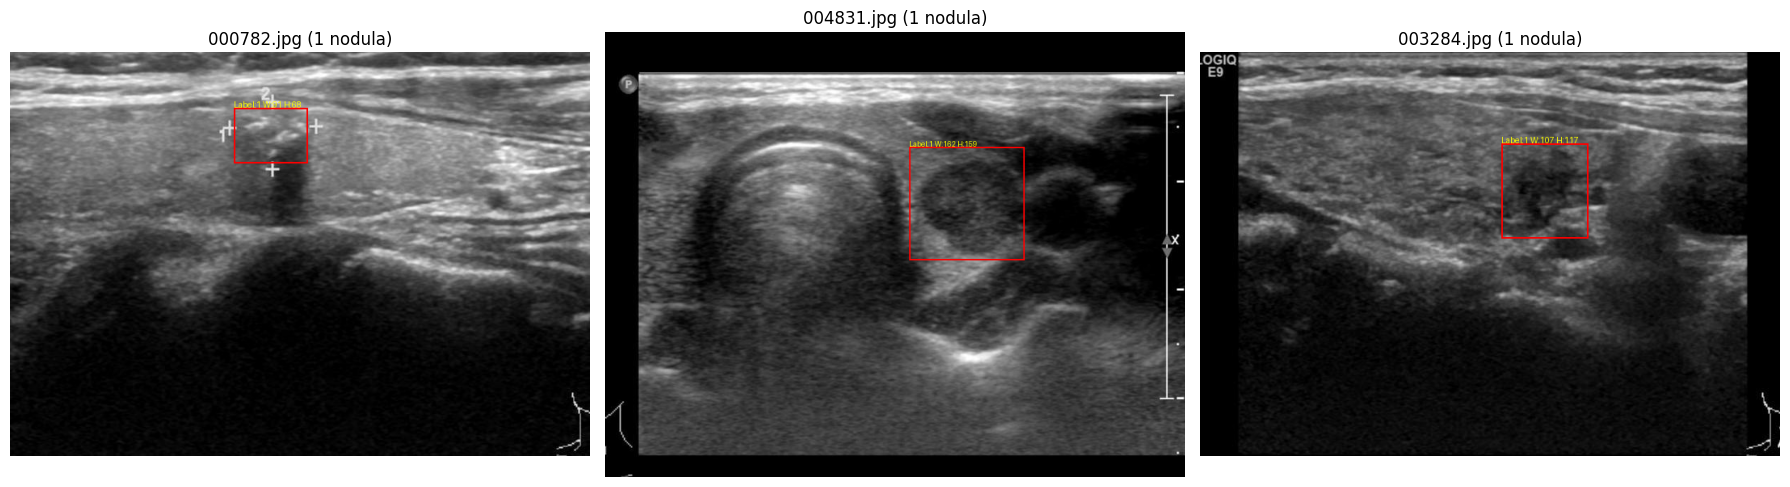

In [ ]:
sample_files = random.sample(image_files, 3)

plt.figure(figsize=(18,6))  

for i, img_file in enumerate(sample_files):
 
    img_path = os.path.join(IMAGE_DIR, img_file)
    img = Image.open(img_path).convert("RGB")
    

    nodules = df[df["image"] == img_file]
    

    draw = ImageDraw.Draw(img)
    for idx, row in nodules.iterrows():
        draw.rectangle([row["xmin"], row["ymin"], row["xmax"], row["ymax"]],
                       outline="red", width=2)
        draw.text((row["xmin"], row["ymin"]-10),
                  f"Label:{row['label']} W:{row['width']} H:{row['height']}",
                  fill="yellow")
    

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"{img_file} ({len(nodules)} nodula)")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Distribucija nodula po klasama

=== Broj nodula po klasi ===
label_name
Maligni    3574
Benigni    1426
Name: count, dtype: int64


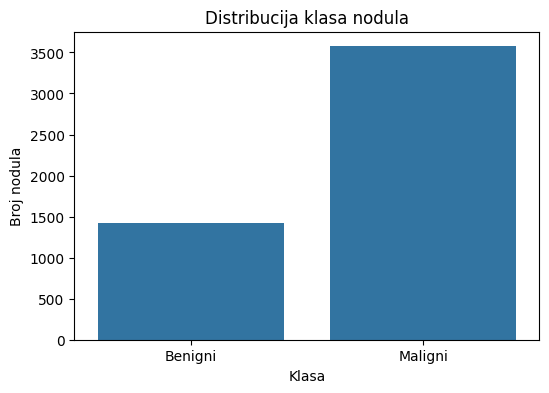

In [ ]:
df["label"] = df["label"].astype(int)

label_map = {0: "Benigni", 1: "Maligni"}
df["label_name"] = df["label"].map(label_map)

print("=== Broj nodula po klasi ===")
print(df["label_name"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="label_name", data=df)
plt.title("Distribucija klasa nodula")
plt.xlabel("Klasa")
plt.ylabel("Broj nodula")
plt.savefig(os.path.join(PLOT_DIR,"label_distribution.png"))
plt.show()

Uočava se da u dataset-u dominiraju maligni noduli, kojih ima 3574, dok je benignih nodula značajno manje, svega 1426. Ovo ukazuje na to da dataset nije potpuno izbalansiran po klasama.

### Distribucija dimenzija nodula

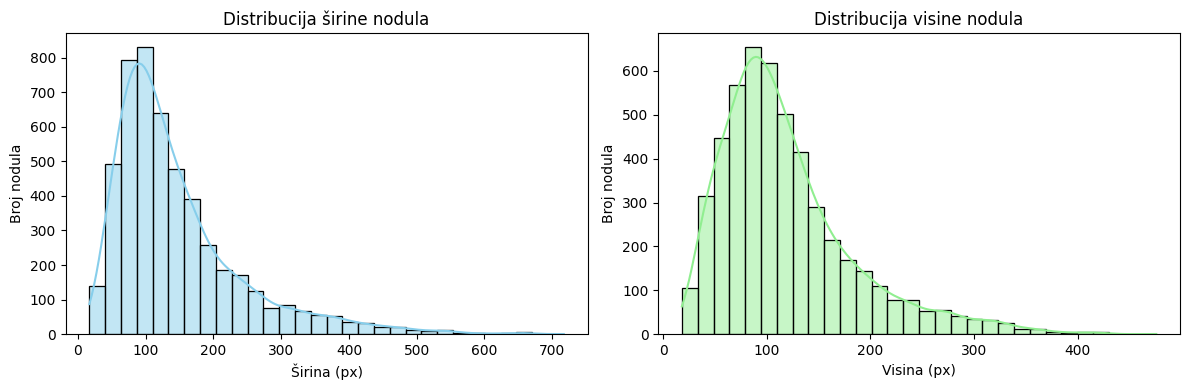

=== Statistika širine nodula ===
count    5000.000000
mean      146.654600
std        96.174855
min        17.000000
25%        82.000000
50%       118.000000
75%       179.000000
max       717.000000
Name: width, dtype: float64

=== Statistika visine nodula ===
count    5000.000000
mean      119.322000
std        65.516077
min        18.000000
25%        75.000000
50%       104.000000
75%       146.000000
max       476.000000
Name: height, dtype: float64
=== Statistika širine nodula ===
count    5000.000000
mean      146.654600
std        96.174855
min        17.000000
25%        82.000000
50%       118.000000
75%       179.000000
max       717.000000
Name: width, dtype: float64

=== Statistika visine nodula ===
count    5000.000000
mean      119.322000
std        65.516077
min        18.000000
25%        75.000000
50%       104.000000
75%       146.000000
max       476.000000
Name: height, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

# Histogram širine
sns.histplot(df["width"], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribucija širine nodula")
axes[0].set_xlabel("Širina (px)")
axes[0].set_ylabel("Broj nodula")

# Histogram visine
sns.histplot(df["height"], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title("Distribucija visine nodula")
axes[1].set_xlabel("Visina (px)")
axes[1].set_ylabel("Broj nodula")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"width_height_distribution.png"))
plt.show()

print("=== Statistika širine nodula ===")
print(df["width"].describe())
print("\n=== Statistika visine nodula ===")
print(df["height"].describe())

Uočen je značajan raspon dimenzija nodula u dataset-u. 

Širina nodula se kreće od minimalnih 17 px do maksimalnih 717 px, sa srednjom vrednošću od oko 147 px i medijanom od 118 px. 

Visina nodula varira između 18 px i 476 px, sa prosekom od oko 119 px i medijanom od 104 px. 

Ovo ukazuje da većina nodula ima relativno male dimenzije, ali postoje i pojedinačni, znatno veći noduli, što se vidi iz vrednosti 75. i 100. percentila. Distribucija širine i visine nodula je blago asimetrična sa desnim repom, što je u skladu sa očekivanim prisustvom retkih, velikih nodula.

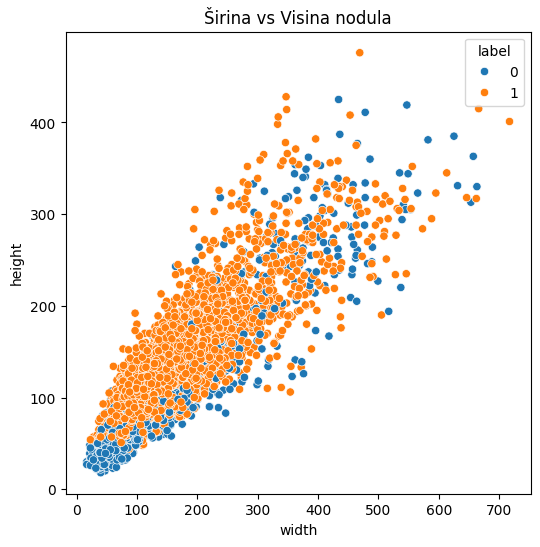

In [67]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="width", y="height", hue="label", data=df)
plt.title("Širina vs Visina nodula")
plt.savefig(os.path.join(PLOT_DIR,"width_height_scatter.png"))
plt.show()

### Odnos proporcija nodula

=== Statistika proporcije nodula (width/height) ===
count    5000.000000
mean        1.226682
std         0.353685
min         0.425926
25%         0.965263
50%         1.177419
75%         1.428571
max         3.339623
Name: ratio, dtype: float64


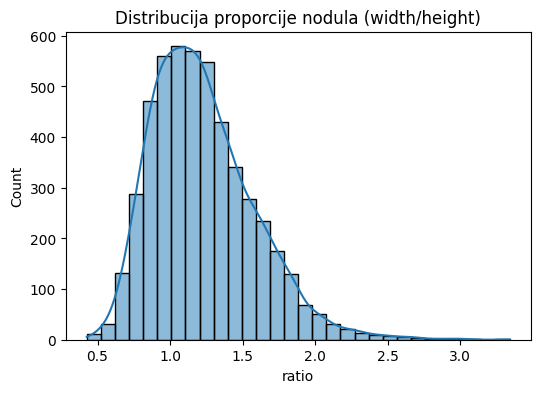

In [69]:
df["ratio"] = df["width"] / df["height"]

print("=== Statistika proporcije nodula (width/height) ===")
print(df["ratio"].describe())

# Crtanje histograma
plt.figure(figsize=(6,4))
sns.histplot(df["ratio"], bins=30, kde=True)
plt.title("Distribucija proporcije nodula (width/height)")
plt.savefig(os.path.join(PLOT_DIR,"width_height_ratio.png"))
plt.show()

Svaki nodul u dataset-u može opisati odnosom svoje širine i visine (width/height). 

Kolona ratio predstavlja ovu proporciju za svaki nodul, što omogućava analizu oblika nodula nezavisno od apsolutne veličine. Histogram proporcija pokazuje da većina nodula ima odnos širine i visine oko 1 do 1.5, što sugeriše da su noduli uglavnom približno kvadratnog ili blago pravougaonog oblika. Ekstremne vrednosti (veoma male ili veoma velike proporcije) ukazuju na neuobičajene ili izdužene nodule, što može biti značajno za dalju analizu karakteristika i potencijalnu klasifikaciju.

### Boxplot-s dimenzija po klasama

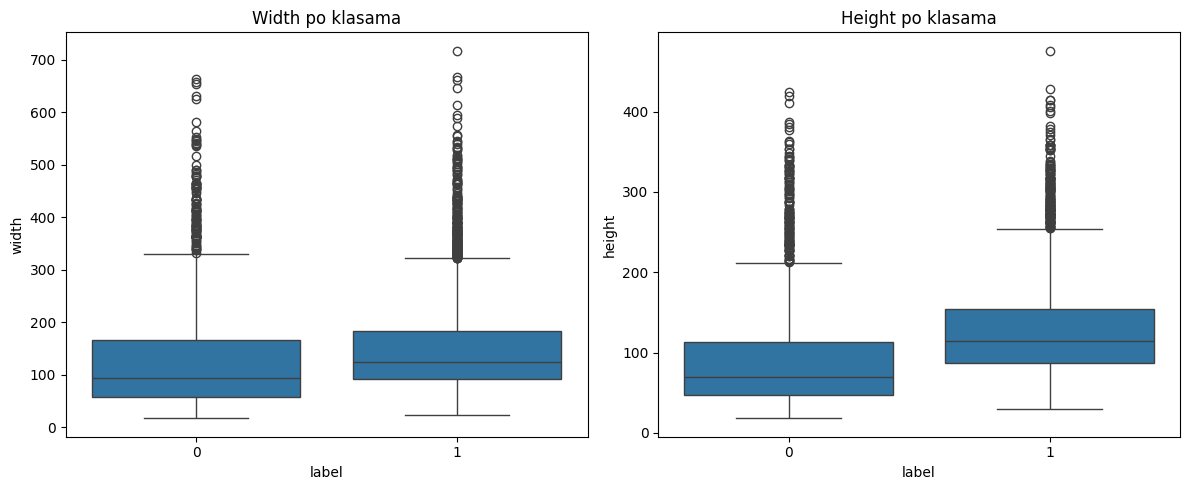

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sns.boxplot(x="label", y="width", data=df, ax=axes[0])
axes[0].set_title("Width po klasama")

sns.boxplot(x="label", y="height", data=df, ax=axes[1])
axes[1].set_title("Height po klasama")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"boxplot_width_height_label.png"))
plt.show()

### Korelacija obeležja

Uočeno je da su numerički atributi nodula međusobno povezani, što je očekivano zbog njihove definicije. Na primer, širina (width) je direktno određena kao razlika između xmax i xmin, a visina (height) kao razlika između ymax i ymin. Zbog toga su atributi poput width i height visoko korelisani sa odgovarajućim koordinatama, dok su xmin i ymin negativno korelisani sa širine i visinom. Ova analiza potvrđuje konzistentnost i logičku pravilnost podataka, ali takođe ukazuje na potencijalnu redundantnost atributa koja može biti relevantna prilikom izgradnje modela za klasifikaciju.

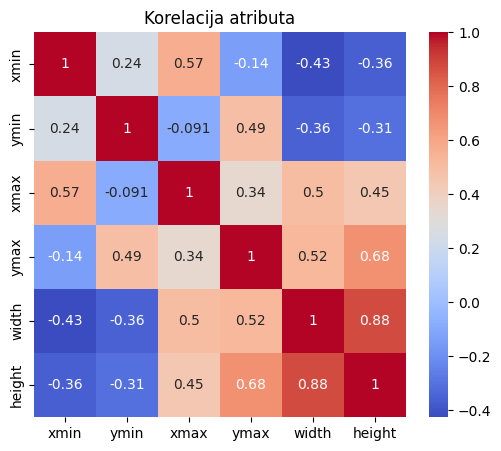

In [74]:
plt.figure(figsize=(6,5))
sns.heatmap(df[["xmin","ymin","xmax","ymax","width","height"]].corr(), annot=True, cmap="coolwarm")
plt.title("Korelacija atributa")
plt.savefig(os.path.join(PLOT_DIR,"correlation_heatmap.png"))
plt.show()

### Analiza ekstremnih vrednosti nodula

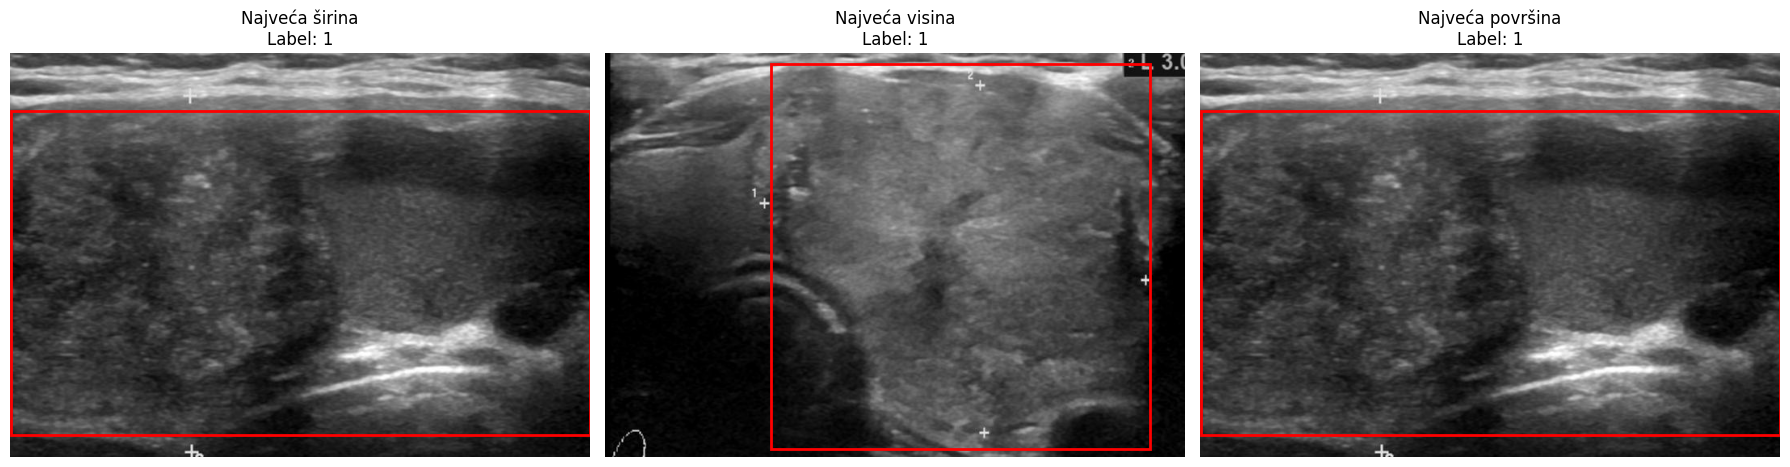

In [77]:
df["area"] = df["width"] * df["height"]

# Pronalaženje nodula sa maksimalnom širinom, visinom i površinom
max_width = df.loc[df["width"].idxmax()]
max_height = df.loc[df["height"].idxmax()]
max_area = df.loc[df["area"].idxmax()]


from PIL import Image
import matplotlib.patches as patches


extremes = {
    "Najveća širina": max_width,
    "Najveća visina": max_height,
    "Najveća površina": max_area
}

fig, axes = plt.subplots(1, 3, figsize=(18,6)) 

for ax, (title, nodule_row) in zip(axes, extremes.items()):
    img_path = os.path.join(IMAGE_DIR, nodule_row["image"])
    img = Image.open(img_path)
    ax.imshow(img)
    
    # Dodavanje bounding box-a
    rect = patches.Rectangle(
        (nodule_row["xmin"], nodule_row["ymin"]),
        nodule_row["width"], nodule_row["height"],
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)
 
    ax.set_title(f"{title}\nLabel: {nodule_row['label']}")
    ax.axis('off') 

plt.tight_layout()
plt.show()